<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-3/HW3_PT2_322512690_212393532_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532

# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import random
from sklearn.manifold import TSNE

# Preprocessing

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]


Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.80MB/s]


Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.82MB/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



# Encoder Class

In [3]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1=nn.Linear(input_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        # get the mean of the latent space
        self.mu=nn.Linear(hidden_dim,latent_dim)
        # get the log var of the latent space
        self.log_var=nn.Linear(hidden_dim,latent_dim)

    def forward(self, x):

      #x=x.view(x.size(0),-1)  #flattern the input
      x=F.relu(self.fc1(x))
      x=F.relu(self.fc2(x))
      mu=self.mu(x)
      log_var=self.log_var(x)

      return mu,log_var


# Decoder Class

In [4]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1=nn.Linear(latent_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,output_dim)



    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x))
        #x=x.view(x.size(0),1,28,28)  # reshape to image format
        return x

# Variational Auto Encoder Class

In [5]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        self.device= device
        self.encoder=Encoder(input_dim,hidden_dim,latent_dim)
        self.decoder=Decoder(input_dim,hidden_dim,latent_dim)


    def reparameterize(self,mu,log_var):

        std=torch.exp(0.5*log_var)
        epslion=torch.randn_like(std)
        z=mu+epslion*std
        return z




    def forward(self, x):
        # write your code here

        x=x.view(x.size(0),-1)
        mu,logvar=self.encoder(x)
        z=self.reparameterize(mu,logvar)
        recon_x=self.decoder(z)
        return recon_x,mu,logvar

In [6]:
model = VAE().to(device)
lr=0.001
optimizer = Adam(model.parameters(), lr)

# Loss Function Class


i add the 1e-10 to avoid log(0)

In [7]:
def loss_function(x, x_hat, mean, log_var):
    # write your code heres

    #x_hat=x_hat.view(x.size(0),-1)

    bce_loss=-torch.sum(x*torch.log(x_hat+ 1e-10)+(1-x)*torch.log(1-x_hat+ 1e-10))


    kld=-0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())

    return bce_loss+kld



    #return torch.mean(bce_loss + kld)

# Training Loop

In [8]:
def train(model, optimizer, epochs, device, x_dim=784): # Modify, add the evaluation step after each 10 epochs
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))

        # After 10 epochs , generate and plot a digit
        if (epoch+1) % 10 ==0:

          with torch.no_grad():

            z=torch.randn(1,model.decoder.fc1.in_features,device=device)

            generated_digit=model.decoder(z).squeeze().cpu().detach().numpy()

            generated_digit=generated_digit.reshape(28,28)

            # plot the generated digit
            plt.imshow(generated_digit,cmap='gray')
            plt.axis('off')
            plt.title(f"Generated Image at Epoch {epoch+1}")
            plt.show()


    return overall_loss

	Epoch 1 	Average Loss:  183.92570889633765
	Epoch 2 	Average Loss:  141.8232957924666
	Epoch 3 	Average Loss:  125.14782521650667
	Epoch 4 	Average Loss:  117.61226996165485
	Epoch 5 	Average Loss:  113.27799799796536
	Epoch 6 	Average Loss:  110.72801940408493
	Epoch 7 	Average Loss:  109.17629400237375
	Epoch 8 	Average Loss:  107.9796374817404
	Epoch 9 	Average Loss:  107.18240769120409
	Epoch 10 	Average Loss:  106.3552453307596


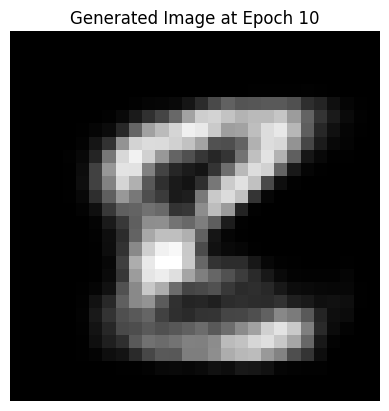

	Epoch 11 	Average Loss:  105.47904316438857
	Epoch 12 	Average Loss:  104.67585767946578
	Epoch 13 	Average Loss:  104.00770705081386
	Epoch 14 	Average Loss:  103.6050288077786
	Epoch 15 	Average Loss:  103.17368829233618
	Epoch 16 	Average Loss:  102.85428577251147
	Epoch 17 	Average Loss:  102.50384734648894
	Epoch 18 	Average Loss:  102.2892139894616
	Epoch 19 	Average Loss:  102.02255032802066
	Epoch 20 	Average Loss:  101.80283594402128


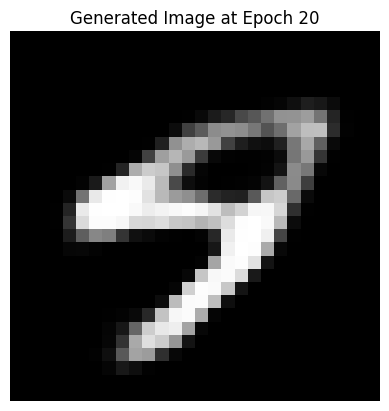

	Epoch 21 	Average Loss:  101.66117471175919
	Epoch 22 	Average Loss:  101.42042621491548
	Epoch 23 	Average Loss:  101.23889896246348
	Epoch 24 	Average Loss:  101.00994869378651
	Epoch 25 	Average Loss:  100.86867238039963
	Epoch 26 	Average Loss:  100.73562074486122
	Epoch 27 	Average Loss:  100.58601174483515
	Epoch 28 	Average Loss:  100.43933810582742
	Epoch 29 	Average Loss:  100.36511852436352
	Epoch 30 	Average Loss:  100.21908731349123


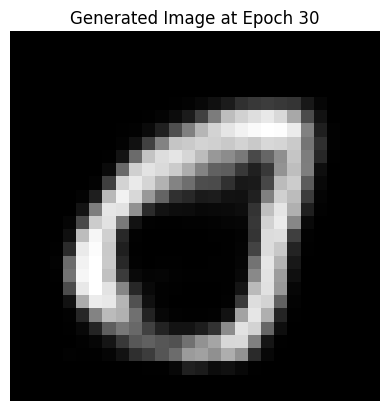

	Epoch 31 	Average Loss:  100.11966405597872
	Epoch 32 	Average Loss:  100.00956654645763
	Epoch 33 	Average Loss:  99.90196465137208
	Epoch 34 	Average Loss:  99.83015644563856
	Epoch 35 	Average Loss:  99.73702608188125
	Epoch 36 	Average Loss:  99.62283731349123
	Epoch 37 	Average Loss:  99.54126010799249
	Epoch 38 	Average Loss:  99.53186577238105
	Epoch 39 	Average Loss:  99.41439210207116
	Epoch 40 	Average Loss:  99.30610284719324


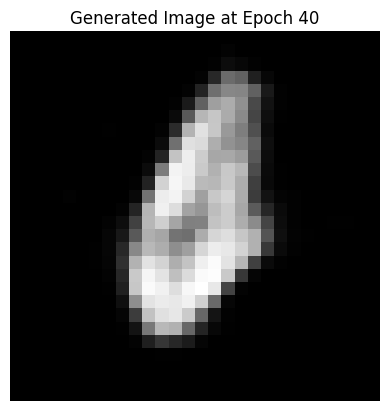

	Epoch 41 	Average Loss:  99.30205045518572
	Epoch 42 	Average Loss:  99.25346291671015
	Epoch 43 	Average Loss:  99.19112712267842
	Epoch 44 	Average Loss:  98.98535022563648
	Epoch 45 	Average Loss:  99.04887633360288
	Epoch 46 	Average Loss:  98.91453242383139
	Epoch 47 	Average Loss:  98.88419545270764
	Epoch 48 	Average Loss:  98.86009591180614
	Epoch 49 	Average Loss:  98.82770212724333
	Epoch 50 	Average Loss:  98.69383930900459


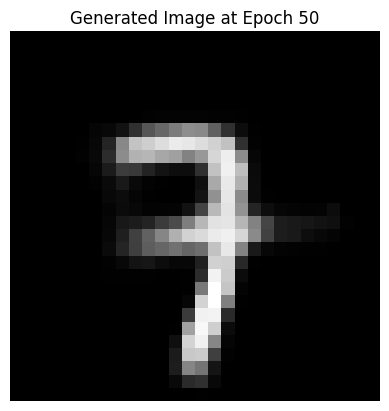

5911760.974609375

In [9]:
train(model, optimizer, epochs=50, device=device)

# Generate and plot digit

In [16]:
import torch
import matplotlib.pyplot as plt

def generate_digit(mean, var):
    """
    Generates and directly plots a handwritten digit using the provided mean and variance.

    Args:
        mean (float or list): Mean of the latent vector.
        var (float or list): Variance of the latent vector.

    Returns:
        None (Plots the generated digit directly)
    """
    model.eval()  # Set model to evaluation mode

    # Ensure `mean` and `var` are tensors of shape `(latent_dim,)`
    if isinstance(mean, float):  # If scalar, expand to (latent_dim,)
        mean = torch.full((model.decoder.fc1.in_features,), mean, dtype=torch.float32).to(device)
    elif isinstance(mean, list):  # Convert list to tensor
        mean = torch.tensor(mean, dtype=torch.float32).to(device)

    if isinstance(var, float):  # If scalar, expand to (latent_dim,)
        var = torch.full((model.decoder.fc1.in_features,), var, dtype=torch.float32).to(device)
    elif isinstance(var, list):  # Convert list to tensor
        var = torch.tensor(var, dtype=torch.float32).to(device)

    with torch.no_grad():
        # Convert variance to standard deviation
        std = torch.sqrt(var)
        # Sample from N(0,1) (random noise)
        eps = torch.randn_like(std).to(device)
        # Apply reparameterization trick: z = mean + eps * std
        z = mean + eps * std

        # Pass latent vector `z` to the decoder
        digit = model.decoder(z.unsqueeze(0)).cpu().view(28, 28)

    # Plot the generated digit directly
    plt.imshow(digit, cmap="gray")
    plt.title(f"Generated digit (mu={mean[0].item()}, var={var[0].item()})")
    plt.axis('off')
    plt.show()


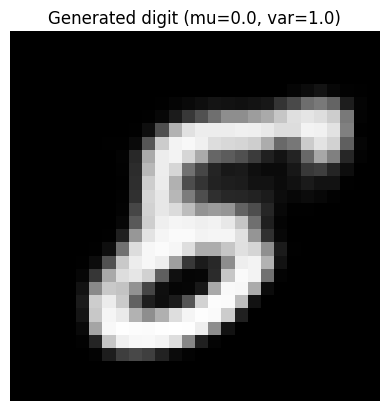

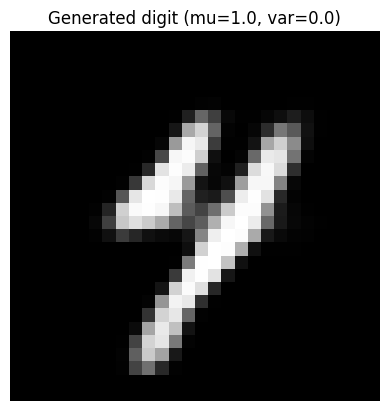

(None, None)

In [17]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

# Latent Space Grid Visualization

In [51]:
def plot_latent_space(model, scale, digit_size=28, figsize=15):

    """
    Plots the latent space by generating a grid of images using t-SNE.

    Args:
        model: The trained VAE model.
        scale: Scaling factor for the latent space.
        digit_size: The size of the generated digits (default 28x28).
        figsize: Figure size for the plot.
    """
    model.eval()  # Set model to evaluation mode

    grid_size = 15  # Define the number of points per row/column
    z_dim = model.encoder.fc2.out_features // 2  # Get latent dimension (200)

    # Generate 5000 random latent samples from normal distribution
    latent_samples = np.random.randn(5000, z_dim)

    # Reduce the latent space from 200D to 2D using t-SNE
    print("Applying t-SNE to reduce latent space...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    latent_2d = tsne.fit_transform(latent_samples)

    # Create a 2D grid based on t-SNE output range
    grid_x = np.linspace(latent_2d[:, 0].min() * scale, latent_2d[:, 0].max() * scale, grid_size)
    grid_y = np.linspace(latent_2d[:, 1].min() * scale, latent_2d[:, 1].max() * scale, grid_size)

    # Create an empty canvas for images
    figure = np.zeros((digit_size * grid_size, digit_size * grid_size))

    # Generate images by decoding latent space grid points
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Find the closest real t-SNE point to interpolate
            closest_idx = np.argmin(np.sum((latent_2d - np.array([xi, yi])) ** 2, axis=1))
            z_sampled = torch.tensor(latent_samples[closest_idx], dtype=torch.float32).to(device).unsqueeze(0)

            with torch.no_grad():
                generated_image = model.decoder(z_sampled).squeeze().cpu().numpy()
                generated_image = generated_image.reshape(digit_size, digit_size)

            # Assign the generated image to the grid
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = generated_image

    # Plot the final latent space visualization
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="gray")
    plt.axis("off")
    plt.title("VAE Latent Space Grid using t-SNE")
    plt.show()

Applying t-SNE to reduce latent space...


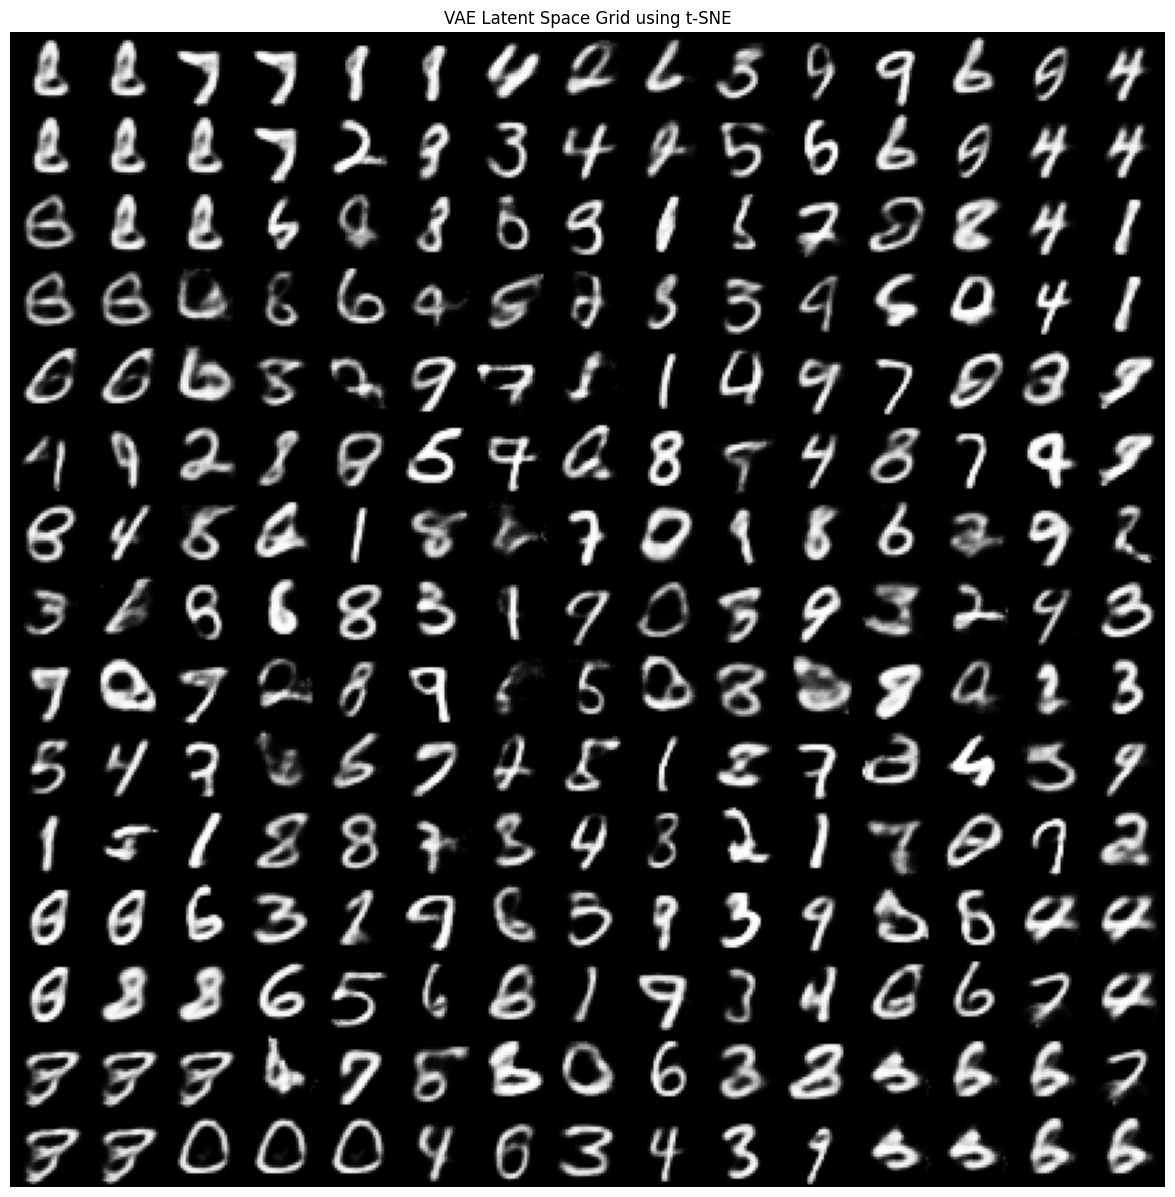

In [52]:
plot_latent_space(model, scale=1.0)

Applying t-SNE to reduce latent space...


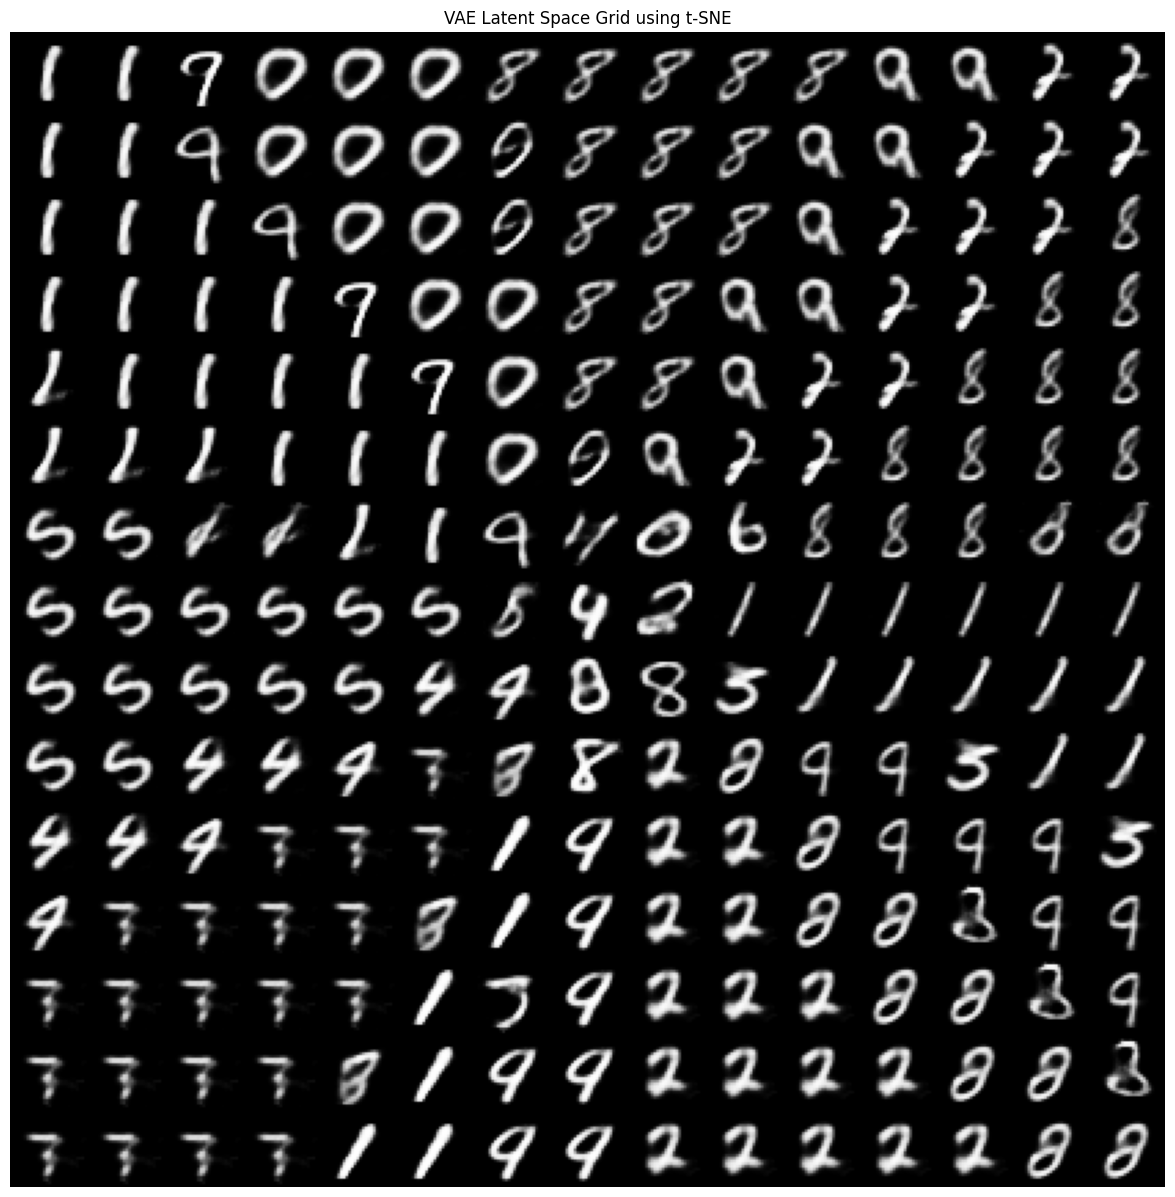

In [53]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

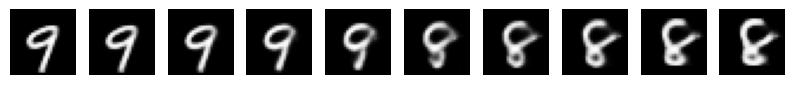

In [54]:
# write your code here
def linear_interpolation(model,dataset,num_steps=10):

  model.eval()

  # select two random digits
  indx1,indx2=random.sample(range(len(dataset)),2)

  img1,label1=dataset[indx1]
  img2,label2=dataset[indx2]



  img1=img1.view(1,-1).to(device)
  img2=img2.view(1,-1).to(device)


  with torch.no_grad():

    mu1,logvar1=model.encoder(img1)
    mu2,logvar2=model.encoder(img2)


    z1=mu1
    z2=mu2


  t_values=torch.linspace(0,1,num_steps,device=device)

  fig,axes=plt.subplots(1,num_steps,figsize=(num_steps,2))


  for i,t in enumerate(t_values):

    z_interpolated=(1-t)*z1 + t*z2

    with torch.no_grad():

      x_decoded=model.decoder(z_interpolated)

    digit_img=x_decoded.squeeze().cpu().detach().numpy()
    digit_img=digit_img.reshape(28,28)

    axes[i].imshow(digit_img,cmap='gray')
    axes[i].axis('off')


  plt.show()





linear_interpolation(model,test_dataset,num_steps=10)

